In [16]:
# ============================================================
# PyBaMM 擬似EIS（AC電流注入 → ナイキスト）
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# ============================================================
# 1. DFNモデル
# ============================================================

model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

# ============================================================
# 2. 充放電サイクル
# ============================================================

experiment = pybamm.Experiment([
    "Charge at 1C until 4.2 V",
    "Hold at 4.2 V until C/20",
    "Rest for 30 minutes",
    "Discharge at 1C until 2.5 V",
    "Rest for 30 minutes",
] * 3)

sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment
)
solution_cycle = sim.solve()


# ============================================================
# 3. AC解析設定
# ============================================================

I0 = 0.5  # [A]
frequencies = [1.0, 0.5, 0.2, 0.1]

Z_real, Z_imag = [], []

# ============================================================
# 4. AC電流入力用 InputParameter
# ============================================================

I_ac = pybamm.InputParameter("I_ac")

param_ac = param.copy()
param_ac.update({
    "Current function [A]": I_ac
})

# ============================================================
# AC解析（Drive cycle方式：PyBaMM正式ルート）
# ============================================================

Z_real, Z_imag = [], []

for f in frequencies:
    print(f"Running AC simulation at {f} Hz")

    omega = 2 * np.pi * f
    T = 1 / f

    # 時間（10周期）
    t_eval = np.linspace(0, 10*T, int(2000*T))
    I_t = I0 * np.sin(omega * t_eval)

    # -------- 時系列電流をInterpolantで定義 --------
    current_function = pybamm.Interpolant(
        t_eval,
        I_t,
        pybamm.t
    )

    param_ac = param.copy()
    param_ac.update({
        "Current function [A]": current_function
    })

    sim_ac = pybamm.Simulation(
        model,
        parameter_values=param_ac
    )

    sol_ac = sim_ac.solve(t_eval)

    # ========================================================
    # 電圧・電流
    # ========================================================

    V = sol_ac["Terminal voltage [V]"].entries
    I = I_t[:len(V)]

    # DC成分除去
    V -= np.mean(V)
    I -= np.mean(I)

    # ========================================================
    # FFTでインピーダンス
    # ========================================================

    dt = t_eval[1] - t_eval[0]
    Vf = np.fft.fft(V)
    If = np.fft.fft(I)
    freqs_fft = np.fft.fftfreq(len(V), dt)

    idx = np.argmin(np.abs(freqs_fft - f))
    Z = Vf[idx] / If[idx]

    Z_real.append(np.real(Z))
    Z_imag.append(np.imag(Z))


2026-02-13 13:11:28.389 - [INFO] base_model._build_model(1185): Start building Doyle-Fuller-Newman model
2026-02-13 13:11:28.435 - [INFO] base_battery_model.build_model(1209): Finish building Doyle-Fuller-Newman model
2026-02-13 13:11:28.440 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 13:11:28.442 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:28.479 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:28.481 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:28.517 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:28.519 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:28.557 - [INFO] par

Running AC simulation at 1.0 Hz


2026-02-13 13:11:30.378 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 13:11:30.383 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 13:11:30.384 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 13:11:30.768 - [INFO] base_solver.solve(1025): Finish solving Doyle-Fuller-Newman model (event: Maximum voltage [V])
2026-02-13 13:11:30.769 - [INFO] base_solver.solve(1026): Set-up time: 134.406 ms, Solve time: 334.662 ms (of which integration time: 333.646 ms), Total time: 469.067 ms
2026-02-13 13:11:30.770 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'
2026-02-13 13:11:30.832 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:30.870 - [INFO] parameter_substitutor.process_model(483): Finish setting 

Running AC simulation at 0.5 Hz


2026-02-13 13:11:31.075 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 13:11:31.080 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 13:11:31.081 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 13:11:31.743 - [INFO] base_solver.solve(1025): Finish solving Doyle-Fuller-Newman model (event: Maximum voltage [V])
2026-02-13 13:11:31.744 - [INFO] base_solver.solve(1026): Set-up time: 135.451 ms, Solve time: 612.228 ms (of which integration time: 611.706 ms), Total time: 747.679 ms
2026-02-13 13:11:31.745 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'
2026-02-13 13:11:31.766 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:31.805 - [INFO] parameter_substitutor.process_model(483): Finish setting 

Running AC simulation at 0.2 Hz


2026-02-13 13:11:32.009 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 13:11:32.015 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 13:11:32.016 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 13:11:33.390 - [INFO] base_solver.solve(1025): Finish solving Doyle-Fuller-Newman model (event: Maximum voltage [V])
2026-02-13 13:11:33.391 - [INFO] base_solver.solve(1026): Set-up time: 144.308 ms, Solve time: 1.316 s (of which integration time: 1.316 s), Total time: 1.461 s
2026-02-13 13:11:33.393 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'
2026-02-13 13:11:33.412 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:11:33.451 - [INFO] parameter_substitutor.process_model(483): Finish setting parameter

Running AC simulation at 0.1 Hz


2026-02-13 13:11:33.657 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 13:11:33.662 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 13:11:33.663 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 13:11:36.186 - [INFO] base_solver.solve(1025): Finish solving Doyle-Fuller-Newman model (event: Maximum voltage [V])
2026-02-13 13:11:36.188 - [INFO] base_solver.solve(1026): Set-up time: 157.101 ms, Solve time: 2.455 s (of which integration time: 2.454 s), Total time: 2.612 s
2026-02-13 13:11:36.189 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'


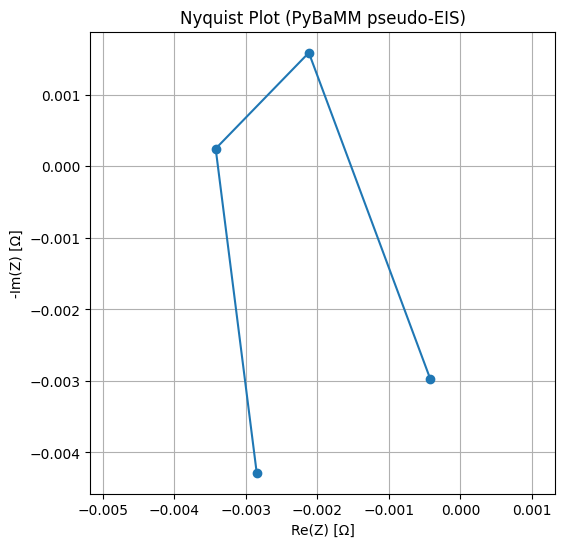

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(Z_real, -np.array(Z_imag), 'o-')
plt.xlabel("Re(Z) [Ω]")
plt.ylabel("-Im(Z) [Ω]")
plt.title("Nyquist Plot (PyBaMM pseudo-EIS)")
plt.grid(True)
plt.axis("equal")
plt.show()


In [18]:
print(Z_real)

[-0.0004244823071176787, -0.0021200922402714205, -0.0034227257483674407, -0.0028491934906081902]


In [19]:
print(-np.array(Z_imag))

[-0.00296694  0.00158891  0.00024778 -0.00428319]


In [22]:
# ============================================================
# PyBaMM 擬似EIS（AC電流注入 → ナイキスト）
# ============================================================

import pybamm
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DFNモデル
# ============================================================

model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

# ============================================================
# 2. 充放電サイクル（劣化後状態）
# ============================================================

# --- 充放電 + 最終Rest ---
experiment = pybamm.Experiment([
    "Charge at 1C until 4.2 V",
    "Hold at 4.2 V until C/20",
    "Rest for 30 minutes",
    "Discharge at 1C until 2.5 V",
    "Rest for 30 minutes",
    "Rest for 2 hours",   # ← ★これを追加
] * 3)


sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment
)
solution_cycle = sim.solve()

# ============================================================
# 4. AC解析（Experiment + Drive Cycle）
# ============================================================

I0 = 0.2
frequencies = [1.0, 0.5, 0.2, 0.1]

Z_real, Z_imag = [], []

for f in frequencies:
    print(f"Running AC simulation at {f} Hz")

    omega = 2 * np.pi * f
    T = 1 / f

    n_cycle = 20
    points_per_cycle = 200
    t_eval = np.linspace(
        0, n_cycle * T, n_cycle * points_per_cycle
    )

    I_t = I0 * np.sin(omega * t_eval)

    # ---- Drive Cycle 用 current ----
    current_function = pybamm.Interpolant(
        t_eval, I_t, pybamm.t
    )

    param_ac = param.copy()
    param_ac.update({
        "Current function [A]": current_function
    })

    # ---- AC Experiment ----
    ac_experiment = pybamm.Experiment([
        pybamm.step.current(current_function, duration=n_cycle*T)
    ])

    sim_ac = pybamm.Simulation(
        model,
        parameter_values=param_ac,
        experiment=ac_experiment
    )

    sol_ac = sim_ac.solve(
        starting_solution=solution_cycle
    )

    # ========================================================
    # 定常部分のみ抽出
    # ========================================================

    V = sol_ac["Terminal voltage [V]"].entries
    I = I_t[:len(V)]

    cut = int(5 * points_per_cycle)
    V = V[-cut:]
    I = I[-cut:]

    V -= np.mean(V)
    I -= np.mean(I)

    # ========================================================
    # FFT → Z
    # ========================================================

    dt = t_eval[1] - t_eval[0]
    Vf = np.fft.fft(V)
    If = np.fft.fft(I)
    freqs_fft = np.fft.fftfreq(len(V), dt)

    idx = np.argmin(np.abs(freqs_fft - f))
    Z = Vf[idx] / If[idx]

    Z_real.append(np.real(Z))
    Z_imag.append(np.imag(Z))


2026-02-13 13:20:41.738 - [INFO] base_model._build_model(1185): Start building Doyle-Fuller-Newman model
2026-02-13 13:20:41.785 - [INFO] base_battery_model.build_model(1209): Finish building Doyle-Fuller-Newman model
2026-02-13 13:20:41.789 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 13:20:41.791 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:20:41.830 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:20:41.832 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:20:41.870 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:20:41.872 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:20:41.911 - [INFO] par

Running AC simulation at 1.0 Hz


2026-02-13 13:20:43.470 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 13:20:43.475 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 13:20:43.476 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 13:20:43.526 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Events ['Minimum voltage [V]'] are non-positive at initial conditions


SolverError: Events ['Minimum voltage [V]'] are non-positive at initial conditions

In [23]:
import pybamm
import numpy as np

model = pybamm.lithium_ion.DFN()

param = pybamm.ParameterValues("Chen2020")

# ===============================
# AC設定
# ===============================
f = 1.0          # Hz
omega = 2 * np.pi * f

I_dc = -0.2      # [A] 放電バイアス（重要）
I_ac = 0.02      # [A] 微小AC

n_cycle = 10
T = 1 / f
t_eval = np.linspace(0, n_cycle*T, 2000)

# ===============================
# 電流関数（DC + AC）
# ===============================
def current_function(t):
    return I_dc + I_ac * np.sin(omega * t)

param_ac = param.copy()
param_ac.update({
    "Current function [A]": current_function
})

# ===============================
# Experimentとして定義（必須）
# ===============================
ac_experiment = pybamm.Experiment([
    pybamm.step.current(current_function, duration=n_cycle*T)
])

sim_ac = pybamm.Simulation(
    model,
    parameter_values=param_ac,
    experiment=ac_experiment
)

sol_ac = sim_ac.solve(
    starting_solution=solution_cycle  # ← ここが Experiment なので OK
)


2026-02-13 13:22:05.997 - [INFO] base_model._build_model(1185): Start building Doyle-Fuller-Newman model
2026-02-13 13:22:06.048 - [INFO] base_battery_model.build_model(1209): Finish building Doyle-Fuller-Newman model
2026-02-13 13:22:06.056 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 13:22:06.057 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:22:06.096 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 13:22:06.099 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-13 13:22:06.212 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-13 13:22:06.213 - [NOTICE] callbacks.on_cycle_start(172): Cycle 18/18 (60.100 us elapsed) --------------------
2026-02-13 13:22:06.214 - [NOTICE] callbacks.on_step_start(180): Cycle 18/18, ste

2026-02-13 16:30:32.912 - [INFO] base_model._build_model(1185): Start building Doyle-Fuller-Newman model
2026-02-13 16:30:32.959 - [INFO] base_battery_model.build_model(1209): Finish building Doyle-Fuller-Newman model
2026-02-13 16:30:32.964 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 16:30:32.965 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:30:33.003 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:30:33.005 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:30:33.042 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:30:33.044 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:30:33.080 - [INFO] par

Running charge/discharge cycles...


2026-02-13 16:30:33.234 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.235 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.345 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.346 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.459 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.460 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.574 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-13 16:30:33.576 - [NOTICE] callbacks.on_cycle_start(172): Cycle 1/15 (68.400 us elapsed) --------------------
2026-02-13 16:30:33.576 - [NOTICE] callbacks.on_step_start(180): Cycle 1/15, step 1/1: 

Running AC simulation at 1.0 Hz


2026-02-13 16:30:34.599 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 16:30:34.604 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 16:30:34.605 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 16:30:34.669 - [NOTICE] callbacks.on_experiment_end(231): Finish experiment simulation, took 150.959 ms
2026-02-13 16:30:34.670 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:30:34.671 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:30:34.672 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:30:34.672 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for mo

Z_real = -159.54815037248252
Z_imag = 69.14616559507574


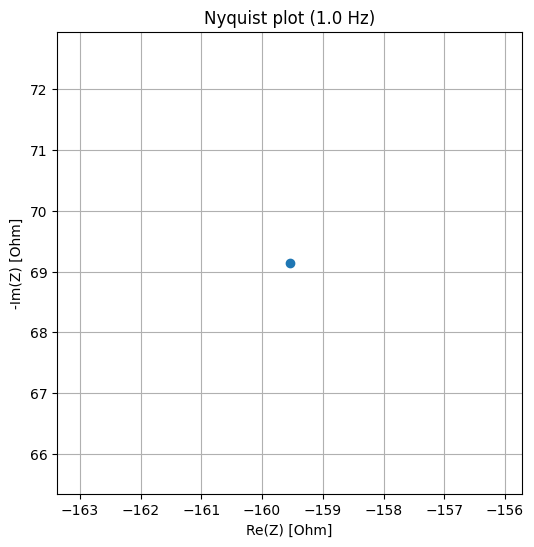

In [25]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

# =====================================================
# 0. モデル・パラメータ
# =====================================================
model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

# =====================================================
# 1. 充放電サイクル（劣化後状態を作る）
# =====================================================
cycle_experiment = pybamm.Experiment([
    "Charge at 0.5C until 4.2 V",
    "Hold at 4.2 V until C/20",
    "Rest for 30 minutes",
    "Discharge at 0.5C until 3.0 V",
    "Rest for 30 minutes",
] * 3)   # ← 必要に応じてサイクル数を増やす

sim_cycle = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=cycle_experiment
)

print("Running charge/discharge cycles...")
solution_cycle = sim_cycle.solve()

# =====================================================
# 2. AC設定（DC + 微小AC）
# =====================================================
f = 1.0                  # [Hz]
omega = 2 * np.pi * f

I_dc = -0.2              # [A] 放電バイアス（必須）
I_ac = 0.02              # [A] 微小AC

n_cycle = 10             # AC周期数
T = 1 / f
t_eval = np.linspace(0, n_cycle * T, 2000)

# =====================================================
# 3. 電流関数（DC + AC）
# =====================================================
def current_function(t):
    return I_dc + I_ac * np.sin(omega * t)

param_ac = param.copy()
param_ac.update({
    "Current function [A]": current_function
})

# =====================================================
# 4. AC Experiment（starting_solution を使うため必須）
# =====================================================
ac_experiment = pybamm.Experiment([
    pybamm.step.current(current_function, duration=n_cycle * T)
])

sim_ac = pybamm.Simulation(
    model,
    parameter_values=param_ac,
    experiment=ac_experiment
)

print(f"Running AC simulation at {f} Hz")
sol_ac = sim_ac.solve(
    starting_solution=solution_cycle
)

# =====================================================
# 5. 定常部分（後半のみ）を抽出
# =====================================================
time = sol_ac["Time [s]"].entries
V = sol_ac["Terminal voltage [V]"].entries
I = current_function(time)

# 最後の 5 周期のみ使用
mask = time > (n_cycle - 5) * T
V_ss = V[mask]
I_ss = I[mask]

# =====================================================
# 6. FFT → インピーダンス算出
# =====================================================
V_fft = fft(V_ss)
I_fft = fft(I_ss)

# 基本周波数成分
Z = V_fft[1] / I_fft[1]

Z_real = np.real(Z)
Z_imag = np.imag(Z)

print("Z_real =", Z_real)
print("Z_imag =", Z_imag)

# =====================================================
# 7. ナイキストプロット
# =====================================================
plt.figure(figsize=(6, 6))
plt.plot(Z_real, Z_imag, "o")
plt.xlabel("Re(Z) [Ohm]")
plt.ylabel("-Im(Z) [Ohm]")
plt.title(f"Nyquist plot ({f} Hz)")
plt.grid(True)
plt.axis("equal")
plt.show()


2026-02-13 16:31:29.797 - [INFO] base_model._build_model(1185): Start building Doyle-Fuller-Newman model
2026-02-13 16:31:29.845 - [INFO] base_battery_model.build_model(1209): Finish building Doyle-Fuller-Newman model
2026-02-13 16:31:29.850 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 16:31:29.851 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model


Running preconditioning cycle...


2026-02-13 16:31:30.311 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.313 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.351 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.353 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.392 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.394 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.431 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:30.434 - [INFO] discretisation.process_model(161): Start discretising

Running AC simulation at 1000.00 Hz


2026-02-13 16:31:31.707 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 16:31:31.712 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 16:31:31.713 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 16:31:31.771 - [NOTICE] callbacks.on_experiment_end(231): Finish experiment simulation, took 143.574 ms
2026-02-13 16:31:31.772 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:31.773 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:31.774 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:31.775 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for mo

...

2026-02-13 16:31:34.660 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 16:31:34.664 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 16:31:34.665 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 16:31:34.727 - [NOTICE] callbacks.on_experiment_end(231): Finish experiment simulation, took 149.904 ms
2026-02-13 16:31:34.729 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:34.737 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:34.754 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 16:31:34.756 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:34.796 - [INF

Running AC simulation at 0.23 Hz


2026-02-13 16:31:34.991 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 16:31:34.996 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 16:31:34.997 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 16:31:35.059 - [NOTICE] callbacks.on_experiment_end(231): Finish experiment simulation, took 145.988 ms
2026-02-13 16:31:35.060 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:35.068 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:35.085 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-13 16:31:35.086 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-13 16:31:35.125 - [INF

Running AC simulation at 0.10 Hz


2026-02-13 16:31:35.326 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-13 16:31:35.332 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-13 16:31:35.333 - [INFO] base_solver.set_up(318): Finish solver set-up
2026-02-13 16:31:35.392 - [NOTICE] callbacks.on_experiment_end(231): Finish experiment simulation, took 150.825 ms
2026-02-13 16:31:35.393 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Time [s]' for model 'Doyle-Fuller-Newman model'
2026-02-13 16:31:35.401 - [INFO] base_model.process_and_register_variable(377): Processing variable 'Terminal voltage [V]' for model 'Doyle-Fuller-Newman model'


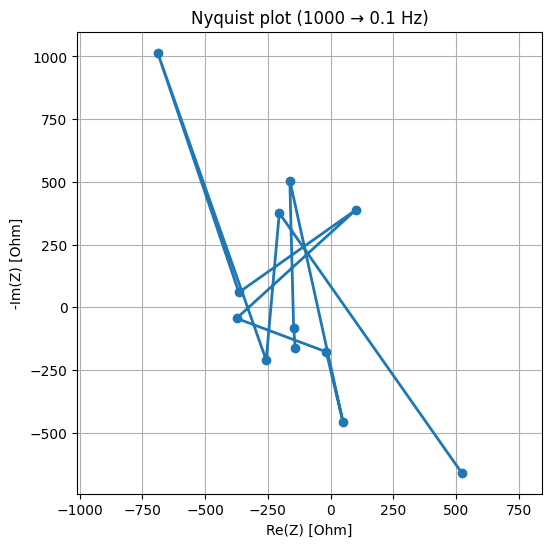

In [26]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

# =====================================================
# 0. モデル・パラメータ
# =====================================================
model = pybamm.lithium_ion.DFN()
param = pybamm.ParameterValues("Chen2020")

# =====================================================
# 1. 事前サイクル（SOC・劣化状態を作る）
# =====================================================
cycle_experiment = pybamm.Experiment([
    "Charge at 0.5C until 4.2 V",
    "Hold at 4.2 V until C/20",
    "Rest for 30 minutes",
    "Discharge at 0.5C until 3.2 V",
    "Rest for 30 minutes",
])

sim_cycle = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=cycle_experiment
)

print("Running preconditioning cycle...")
solution_cycle = sim_cycle.solve()

# =====================================================
# 2. 周波数 sweep 設定
# =====================================================
freqs = np.logspace(3, -1, 12)   # 1000 → 0.1 Hz（12点）

I_dc = -0.2     # [A] DCバイアス（重要）
I_ac = 0.02     # [A] 微小AC
n_cycle = 8     # 各周波数でのAC周期数

Z_real = []
Z_imag = []

# =====================================================
# 3. 周波数 sweep ループ
# =====================================================
for f in freqs:
    print(f"Running AC simulation at {f:.2f} Hz")

    omega = 2 * np.pi * f
    T = 1 / f

    # ---- 電流関数 ----
    def current_function(t):
        return I_dc + I_ac * np.sin(omega * t)

    param_ac = param.copy()
    param_ac.update({
        "Current function [A]": current_function
    })

    # ---- Experiment ----
    ac_experiment = pybamm.Experiment([
        pybamm.step.current(current_function, duration=n_cycle * T)
    ])

    sim_ac = pybamm.Simulation(
        model,
        parameter_values=param_ac,
        experiment=ac_experiment
    )

    sol_ac = sim_ac.solve(
        starting_solution=solution_cycle
    )

    # =================================================
    # 4. 定常部分抽出（後半 50%）
    # =================================================
    time = sol_ac["Time [s]"].entries
    V = sol_ac["Terminal voltage [V]"].entries
    I = current_function(time)

    mask = time > (n_cycle * T * 0.5)
    V_ss = V[mask]
    I_ss = I[mask]

    # =================================================
    # 5. FFT → インピーダンス
    # =================================================
    V_fft = fft(V_ss)
    I_fft = fft(I_ss)

    Z = V_fft[1] / I_fft[1]

    Z_real.append(np.real(Z))
    Z_imag.append(np.imag(Z))

# =====================================================
# 6. ナイキストプロット
# =====================================================
plt.figure(figsize=(6, 6))
plt.plot(Z_real, -np.array(Z_imag), "o-", lw=2)
plt.xlabel("Re(Z) [Ohm]")
plt.ylabel("-Im(Z) [Ohm]")
plt.title("Nyquist plot (1000 → 0.1 Hz)")
plt.grid(True)
plt.axis("equal")
plt.show()
